In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from pandas.api.types import is_numeric_dtype
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.metrics import confusion_matrix,roc_curve,roc_auc_score

In [40]:
df = pd.read_csv("customer_churn_prediction.csv")

In [41]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00000,Male,1,No,Yes,4,Yes,No phone service,Fiber optic,No internet service,...,No internet service,No,Yes,Yes,One year,No,Mailed check,37.41,198.39,Yes
1,CUST00001,Male,0,No,No,68,Yes,Yes,DSL,No,...,Yes,Yes,No,No,One year,Yes,Credit card (automatic),99.85,6837.27,No
2,CUST00002,Male,1,Yes,Yes,56,No,No phone service,DSL,No internet service,...,No,Yes,No,No,One year,Yes,Electronic check,110.92,6250.14,No
3,CUST00003,Male,0,No,No,49,No,Yes,Fiber optic,No internet service,...,No,Yes,No internet service,No,Two year,Yes,Mailed check,112.37,5506.34,No
4,CUST00004,Male,0,Yes,No,16,Yes,No,DSL,No internet service,...,No,No internet service,No,Yes,Month-to-month,Yes,Bank transfer (automatic),51.43,872.40,Yes


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1000 non-null   object 
 1   gender            1000 non-null   object 
 2   SeniorCitizen     1000 non-null   int64  
 3   Partner           1000 non-null   object 
 4   Dependents        1000 non-null   object 
 5   tenure            1000 non-null   int64  
 6   PhoneService      1000 non-null   object 
 7   MultipleLines     1000 non-null   object 
 8   InternetService   1000 non-null   object 
 9   OnlineSecurity    1000 non-null   object 
 10  OnlineBackup      1000 non-null   object 
 11  DeviceProtection  1000 non-null   object 
 12  TechSupport       1000 non-null   object 
 13  StreamingTV       1000 non-null   object 
 14  StreamingMovies   1000 non-null   object 
 15  Contract          1000 non-null   object 
 16  PaperlessBilling  1000 non-null   object 
 

In [43]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,0.51000,36.886000,69.872450,2566.954530
std,0.50015,20.521651,29.556253,1863.955466
min,0.00000,0.000000,20.040000,3.290000
25%,0.00000,20.000000,44.952500,1089.820000
50%,1.00000,37.000000,70.010000,2096.465000
75%,1.00000,54.000000,96.440000,3680.255000
max,1.00000,72.000000,119.920000,8371.520000


In [44]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [47]:
le = LabelEncoder()
mms = MinMaxScaler()

In [48]:
for col in df.columns:
    if not is_numeric_dtype(df[col]):
        df[col] = le.fit_transform(df[col])
    else:
        df[col] = mms.fit_transform(df[[col]])

In [49]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,1.0,0,1,0.055556,1,1,1,1,...,1,0,2,2,1,0,3,0.173909,0.023314,1
1,1,1,0.0,0,0,0.944444,1,2,0,0,...,2,2,0,0,1,1,1,0.799059,0.816658,0
2,2,1,1.0,1,1,0.777778,0,1,0,1,...,0,2,0,0,1,1,2,0.909892,0.746496,0
3,3,1,0.0,0,0,0.680556,0,2,1,1,...,0,2,1,0,2,1,3,0.924409,0.657612,0
4,4,1,0.0,1,0,0.222222,1,0,0,1,...,0,1,0,2,0,1,0,0.314277,0.103858,1


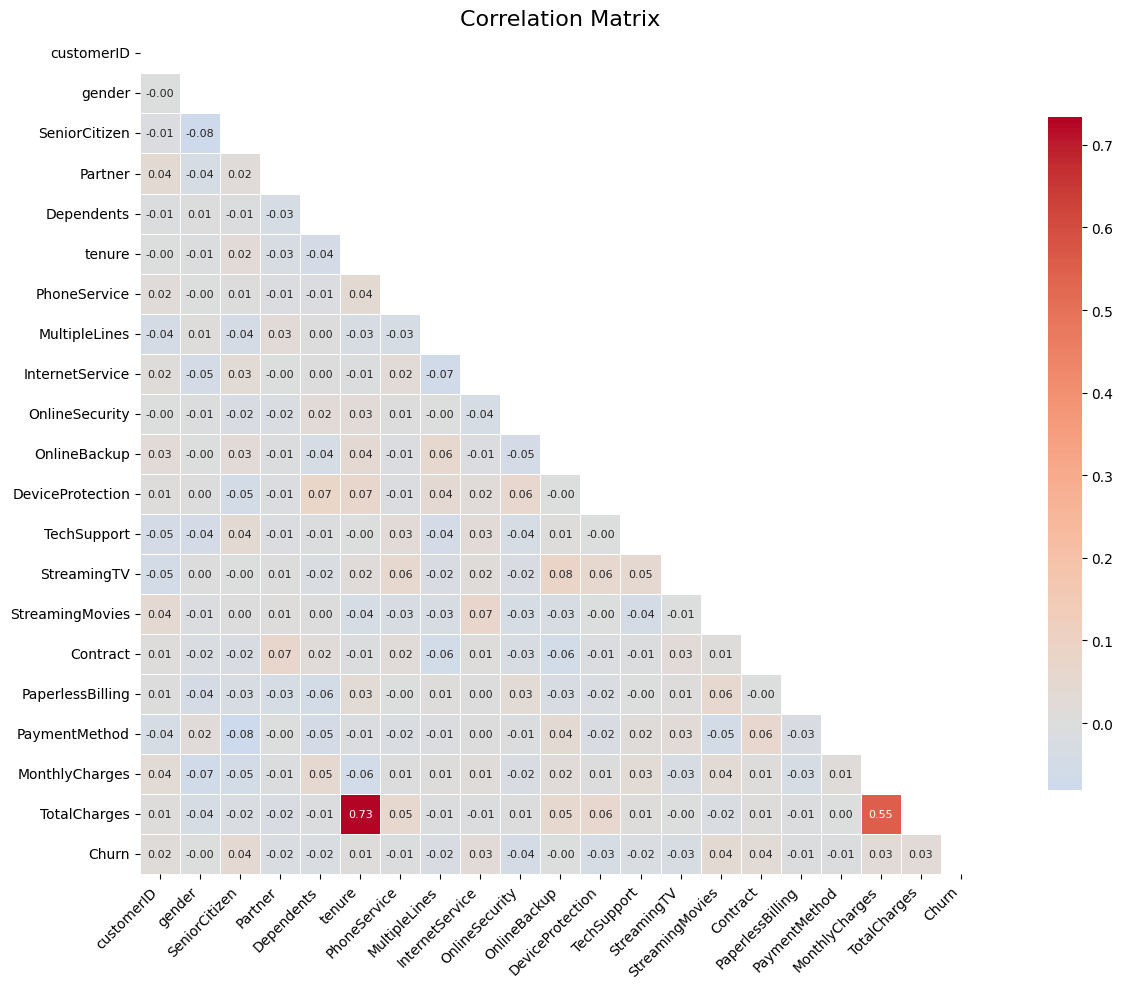

In [50]:
plt.figure(figsize=(14, 10))

corr = df.corr()

mas = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mas,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)

plt.xticks(rotation=45, ha='right')
plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

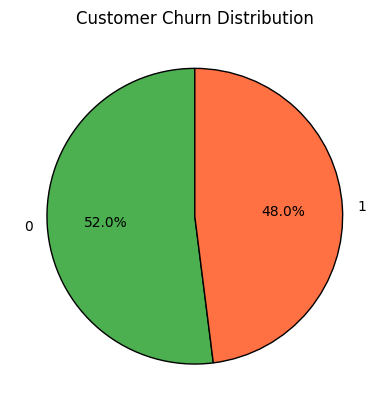

In [51]:
df["Churn"].value_counts().plot(
    kind="pie",
    autopct='%1.1f%%',
    startangle=90,
    colors=["#4CAF50", "#FF7043"],
    wedgeprops={'edgecolor': 'black'},
)
plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.show()

In [52]:
x = df.drop(["Churn"],axis=1)
y = df[["Churn"]]

In [53]:
dt = DecisionTreeClassifier()

In [54]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=.2,random_state=42)

In [55]:
model = dt.fit(xtrain,ytrain)

In [56]:
model.score(xtrain,ytrain)

1.0

In [57]:
model.score(xtest,ytest)

0.53

In [58]:
pred_y1 = model.predict(xtest)

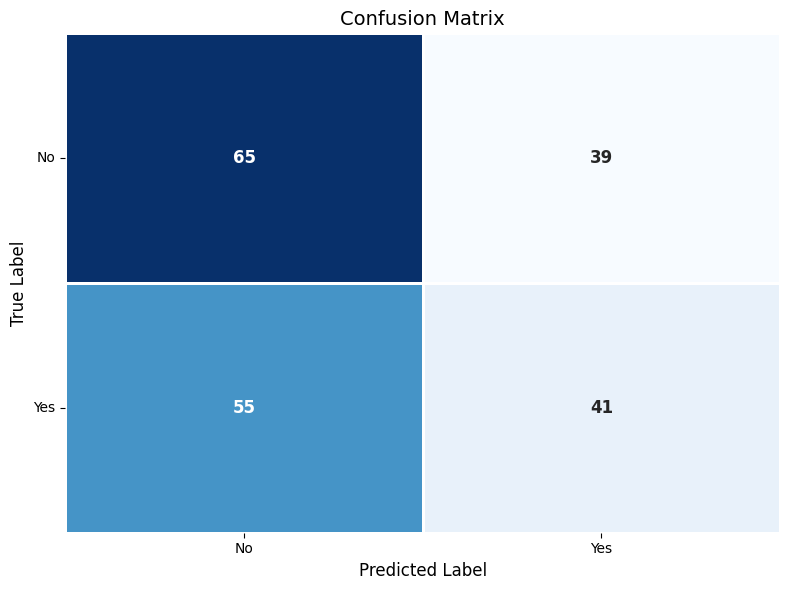

In [59]:
cm = confusion_matrix(ytest,pred_y1)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="white",
    cbar=False,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.xticks([0.5, 1.5], ["No", "Yes"])
plt.yticks([0.5, 1.5], ["No", "Yes"], rotation=0)
plt.tight_layout()
plt.show()

In [60]:
parameter= {"criterion":['gini',"entropy","log_loss"],
            "ccp_alpha": [1.0,.01,.1,.001],
            "max_depth":[10,8,12],
            "splitter":['best', "random"]}

In [61]:
gscv = GridSearchCV(dt,param_grid=parameter,verbose=2)
gscv

,estimator,DecisionTreeClassifier()
,param_grid,"{'ccp_alpha': [1.0, 0.01, ...], 'criterion': ['gini', 'entropy', ...], 'max_depth': [10, 8, ...], 'splitter': ['best', 'random']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [62]:
model1 = gscv.fit(xtrain,ytrain)
model1.score(xtrain,ytrain)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END ccp_alpha=1.0, criterion=gini, max_depth=10, splitter=best; total time=   0.0s
[CV] END ccp_alpha=1.0, criterion=gini, max_depth=10, splitter=best; total time=   0.0s
[CV] END ccp_alpha=1.0, criterion=gini, max_depth=10, splitter=best; total time=   0.0s
[CV] END ccp_alpha=1.0, criterion=gini, max_depth=10, splitter=best; total time=   0.0s
[CV] END ccp_alpha=1.0, criterion=gini, max_depth=10, splitter=best; total time=   0.0s
[CV] END ccp_alpha=1.0, criterion=gini, max_depth=10, splitter=random; total time=   0.0s
[CV] END ccp_alpha=1.0, criterion=gini, max_depth=10, splitter=random; total time=   0.0s
[CV] END ccp_alpha=1.0, criterion=gini, max_depth=10, splitter=random; total time=   0.0s
[CV] END ccp_alpha=1.0, criterion=gini, max_depth=10, splitter=random; total time=   0.0s
[CV] END ccp_alpha=1.0, criterion=gini, max_depth=10, splitter=random; total time=   0.0s
[CV] END ccp_alpha=1.0, criterion=gini, max_dept

0.52

In [63]:
model1.score(xtest,ytest)

0.52

In [64]:
pred_y2 = model1.predict(xtest)

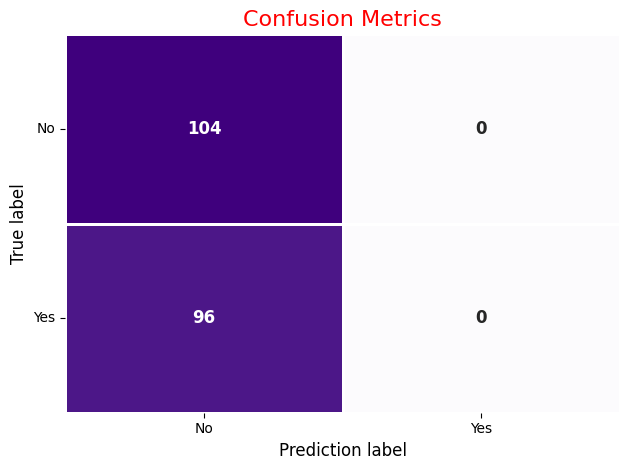

In [65]:
cm1 = confusion_matrix(ytest,pred_y2)
sns.heatmap(
    cm1,
    annot=True,
    fmt = "g",
    cmap="Purples",
    linewidths=1,
    linecolor="white",
    cbar=False,
    annot_kws={"size":12,"weight":"bold"}
)
plt.xlabel("Prediction label",fontsize=12)
plt.ylabel("True label",fontsize=12)
plt.title("Confusion Metrics",fontsize = 16,color = "r")
plt.xticks([0.5,1.5],["No","Yes"])
plt.yticks([0.5,1.5],["No","Yes"],rotation=0)
plt.tight_layout()
plt.show()

In [66]:
rscv = RandomizedSearchCV(
    dt,
    param_distributions=parameter,
    n_iter=10,
    verbose=2,
    random_state=42
)

In [67]:
model2 = rscv.fit(xtrain,ytrain)
model2.score(xtrain,ytrain)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ccp_alpha=1.0, criterion=gini, max_depth=12, splitter=best; total time=   0.0s
[CV] END ccp_alpha=1.0, criterion=gini, max_depth=12, splitter=best; total time=   0.0s
[CV] END ccp_alpha=1.0, criterion=gini, max_depth=12, splitter=best; total time=   0.0s
[CV] END ccp_alpha=1.0, criterion=gini, max_depth=12, splitter=best; total time=   0.0s
[CV] END ccp_alpha=1.0, criterion=gini, max_depth=12, splitter=best; total time=   0.0s
[CV] END ccp_alpha=0.001, criterion=entropy, max_depth=8, splitter=best; total time=   0.0s
[CV] END ccp_alpha=0.001, criterion=entropy, max_depth=8, splitter=best; total time=   0.0s
[CV] END ccp_alpha=0.001, criterion=entropy, max_depth=8, splitter=best; total time=   0.0s
[CV] END ccp_alpha=0.001, criterion=entropy, max_depth=8, splitter=best; total time=   0.0s
[CV] END ccp_alpha=0.001, criterion=entropy, max_depth=8, splitter=best; total time=   0.0s
[CV] END ccp_alpha=0.01, criterion=gini

0.52

In [68]:
model2.score(xtest,ytest)

0.52

In [69]:
pred_y3 = model2.predict(xtest)

In [71]:
cm2= confusion_matrix(ytest,pred_y3)

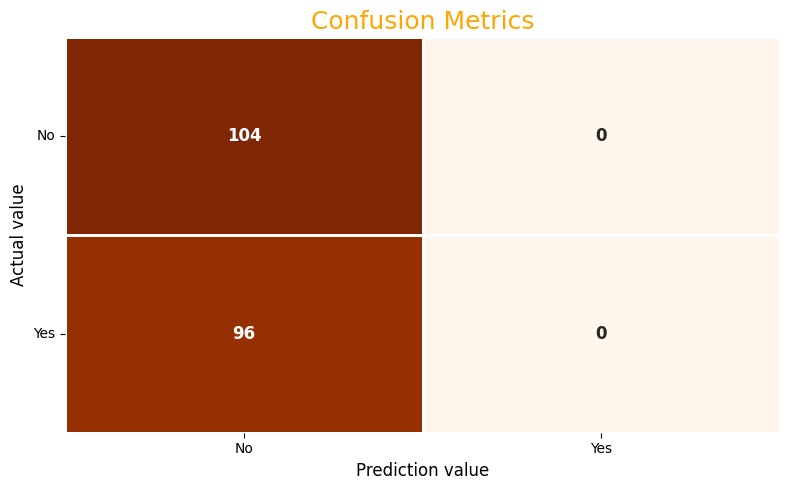

In [80]:
plt.figure(figsize=(8,5))
sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Oranges",
    linewidths=1,
    linecolor="white",
    cbar=False,
    annot_kws={"size":12,"weight":"bold"}
)
plt.xlabel("Prediction value", fontsize=12)
plt.ylabel("Actual value",fontsize=12)
plt.title("Confusion Metrics",fontsize = 18,color="orange")
plt.xticks([0.5,1.5],["No","Yes"])
plt.yticks([0.5,1.5],["No","Yes"],rotation=0)
plt.tight_layout()
plt.show()

In [82]:
xtest.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [87]:
# Decesion Tree
y_proba = model.predict_proba(xtest)[:,1]
fpr,tpr, _ = roc_curve(ytest,y_proba)
auc = roc_auc_score(ytest,y_proba)

In [88]:
# GridsearchCV
y_proba1 = model1.predict_proba(xtest)[:,1]
fpr1,tpr1,_ = roc_curve(ytest,y_proba1)
auc1 = roc_auc_score(ytest,y_proba1)

In [89]:
# RandomsearchCV
y_proba2 = model2.predict_proba(xtest)[:,1]
fpr2,tpr2,_ = roc_curve(ytest,y_proba2)
auc2 = roc_auc_score(ytest,y_proba2)

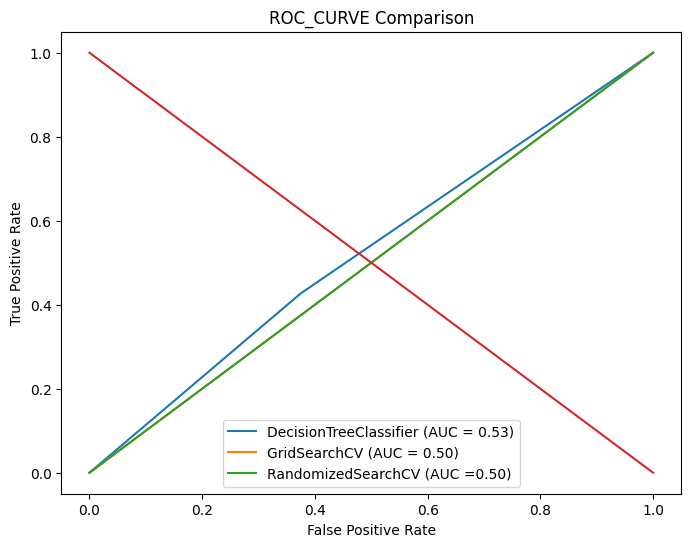

In [90]:
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label =f"DecisionTreeClassifier (AUC = {auc:.2f})")
plt.plot(fpr1,tpr1 ,label=f"GridSearchCV (AUC = {auc1:.2f})")
plt.plot(fpr2,tpr2, label = f"RandomizedSearchCV (AUC ={auc2:.2f})")

plt.plot([0,1],[1,0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC_CURVE Comparison")
plt.legend()
plt.show()